In [21]:
import pandas as pd

df = pd.read_csv(r"C:\Users\USER\Downloads\SuperStoreOrders.csv\SuperStoreOrders.csv")

In [22]:
df.shape

(51290, 21)

In [23]:
# checking if there are any null values in dataset

pd.isnull(df).sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

In [24]:
# converting the datatype of sales column to float

df['sales'] = pd.to_numeric(df['sales'], errors='coerce')

In [25]:
# sice we got the missing values after converting the datype of the column sales. So, handaling the missing data

df.dropna(subset=['sales'], inplace=True)

 ## Sales and Profit Analysis
 
 


In [26]:
# What is the total sales and profit for each region?

result = df.groupby(['region'], as_index=False)[['sales', 'profit']].sum().sort_values(by='profit', ascending=False)

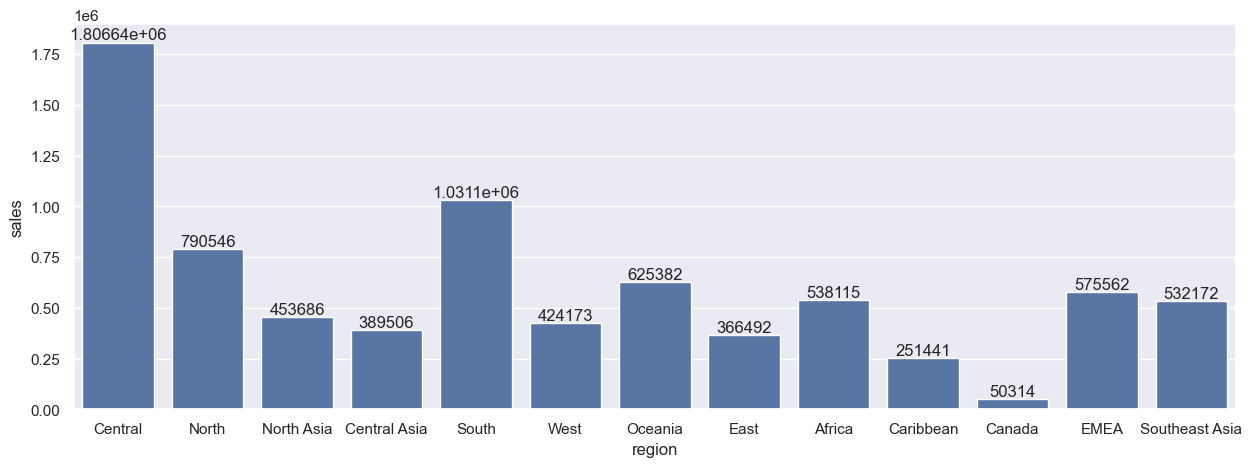

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# plotting total sales
sns.set(rc={'figure.figsize': (15, 5)})

ax = sns.barplot(data=result, x='region', y='sales')

for bars in ax.containers:
    ax.bar_label(bars)

plt.show()

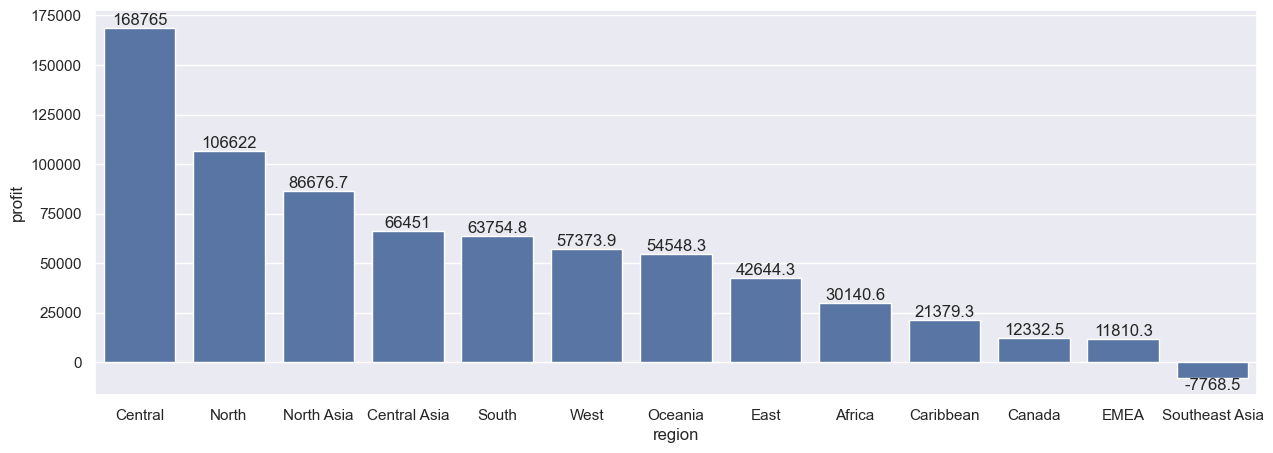

In [30]:
# plotting total profit

ax = sns.barplot(data=result, x='region', y='profit')
for bars in ax.containers:
    ax.bar_label(bars)
    
plt.show()

# So, we found the total sales and profit of each region and also found Central Region has the highest number of sales and profit¶

In [31]:
# Which product have the highest sales and profit margins?

#firstly, grouping by product_id and getting total sales and profit
product_sales = df.groupby('product_id').agg({
    'product_name': 'first',
    'sales': 'sum',
    'profit': 'sum'
}).reset_index()

#calculating the profit margin by adding new column to the dataset
product_sales['Profit Margin'] = (product_sales['profit'] / product_sales['sales']) * 100

#identifying the product with highest sales
highest_sale_product = product_sales.sort_values(by='sales', ascending=False).head(1)
print('Product with highest sales:')
print(highest_sale_product[['product_name', 'sales']])

print('\n')

#identifying the product with highest profit margin
highest_profit_product = product_sales.sort_values(by='profit', ascending=False).head(1)
print('Product with highest profit:')
print(highest_profit_product[['product_name', 'profit']])

Product with highest sales:
                  product_name   sales
814  Novimex Bag Chairs, Black  8184.0


Product with highest profit:
                   product_name    profit
6908  Eldon Lockers, Industrial  2923.758


# Customer Analysis

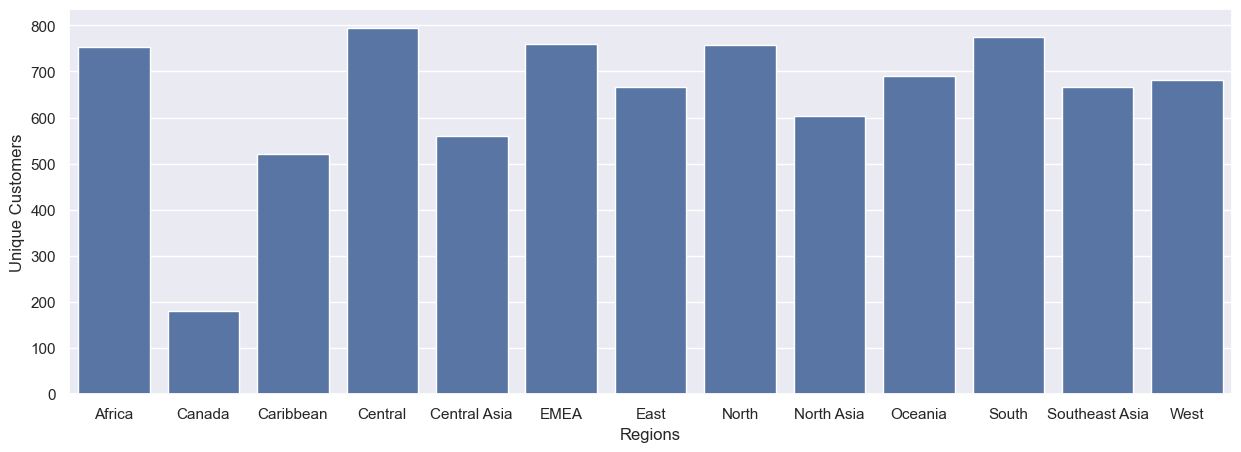

In [33]:
# What is the distribution of customers across different regions?

#firstly, identifying the unique customers
customers_per_region = df.groupby('region')['customer_name'].nunique().reset_index()

#now, visualizing the data
sns.barplot(data=customers_per_region, x='region', y='customer_name')
plt.ylabel('Unique Customers')
plt.xlabel('Regions')
plt.show()

In [34]:
# Who are the top customers in terms of sale and profit?

#firstly, grouping by customer_name and getting sales and profit
customers = df.groupby('customer_name').agg({
    'sales': 'sum',
    'profit': 'sum'
})

top_cust_by_sales = customers.sort_values(by='sales', ascending=False).head(10)
top_cust_by_profit = customers.sort_values(by='profit', ascending=False).head(10)

print(top_cust_by_sales)
print('\n')
print(top_cust_by_profit)

                    sales      profit
customer_name                        
Eric Murdock      19489.0  2450.54748
John Grady        19483.0  2870.44010
Maria Etezadi     18237.0  1822.93410
Theone Pippenger  17416.0  1859.91698
Dan Reichenbach   16705.0  1984.39860
Ben Ferrer        16661.0  2358.05394
Randy Bradley     16399.0  2429.66442
Mathew Reese      16125.0  3105.12260
Muhammed Yedwab   16091.0   488.46508
Steven Ward       15984.0  1217.34060


                   sales      profit
customer_name                       
Katharine Harms  14912.0  3400.16880
Mathew Reese     16125.0  3105.12260
Brian Moss       13098.0  3028.13338
Sanjit Engle     14130.0  3007.02352
John Grady       19483.0  2870.44010
Bill Shonely     12008.0  2839.77056
Larry Tron       11362.0  2804.89294
Jim Karlsson     13083.0  2791.22160
Neil Knudson     11034.0  2790.40890
Laura Armstrong  14831.0  2773.70620


# Category and Sub-Category Analysis

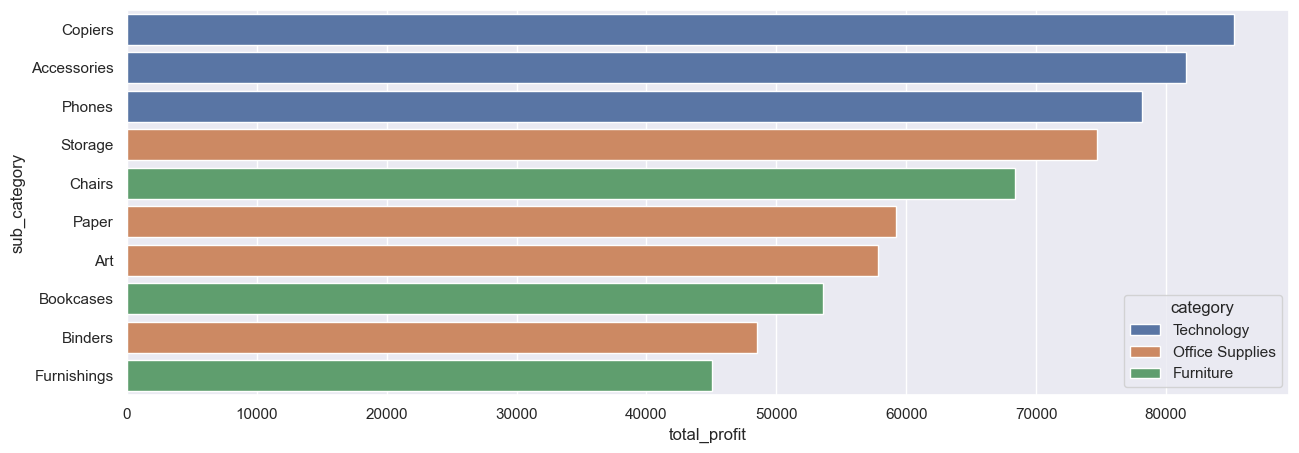

In [35]:
# Which categories and sub-categories are the most profitable

#firstly, calculating the total and average profit for each category and sub-category
profit = df.groupby(['category', 'sub_category'], as_index=False).agg({
    'profit': ['sum', 'mean']
})

#renaming the columns name
profit.columns = ['category', 'sub_category', 'total_profit', 'average_profit']

#sorting by total profit
result = profit.sort_values(by='total_profit', ascending=False).head(10)

#visualizing the data
sns.barplot(data=result, x='total_profit', y='sub_category', hue='category')
plt.show()